# Why Deep Learning?

## Start with something we do without thinking

Imagine an envelope with a handwritten address. You look at a digit and recognize it as a five. Another person writes the same digit with a different shape, and you can still recognize it.

Now imagine asking a computer to do that.

The computer does not receive the word “five.” It receives a grid of numbers describing how bright or dark each tiny part of the image is. Those tiny parts are called **pixels**. A dark stroke becomes one collection of numbers; the white background becomes another.

We want the computer to turn those measurements into an answer. But the measurements can change even when the answer stays the same. The digit might move slightly to the left. The pen might make a thicker line. Someone might write it at an angle.

This is where the problem becomes interesting. A useful system needs to recognize the important pattern while allowing these differences.

Deep learning is one way to learn such patterns. To understand why we might need it, we will first look at what makes a problem easy or difficult for a model. Then we will work through a small example whose numbers we can calculate ourselves.

The [code companion](01_Why_Deep_Learning.ipynb) makes that small example runnable. Everything needed to understand the lesson is explained here.

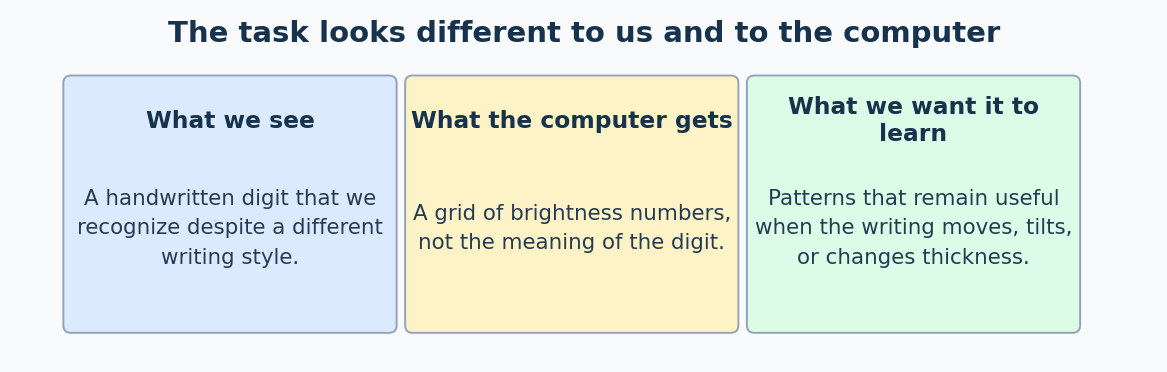

## Start with the problem this lesson solves

Suppose a sensor reports a point's two coordinates, and we must say whether it is outside a circular safe zone. The input is two numbers, $x_1,x_2$; the target is zero inside and one outside. A straight decision boundary cannot surround the center while labeling the whole outside differently.

An **artificial neural network (ANN)** can build intermediate features and combine them into a nonlinear decision. This matters when the useful features are not already known. If we already know the circle's equation, a direct calculation is simpler. Deep learning is useful because it can learn representations from examples, not because every problem needs a large model.

## Follow a small example from coordinates to a decision

**First solve it with a known feature.** For a unit circle, compute $r^2=x_1^2+x_2^2$ and predict one when $r^2>1$.

| Point | Square the coordinates | Add | Decision |
| --- | --- | --- | --- |
| $(0.3,0.4)$ | $0.09,0.16$ | $0.25$ | Inside: zero |
| $(0.8,0.8)$ | $0.64,0.64$ | $1.28$ | Outside: one |
| $(-0.8,-0.8)$ | $0.64,0.64$ | $1.28$ | Outside: one |
| $(0,0)$ | $0,0$ | $0$ | Inside: zero |

Squaring is doing an important job: positive and negative coordinates both contribute to distance. Merely adding signed coordinates would cancel some distant points.

**Now inspect a tiny ANN whose weights we choose by hand.** This is an illustration of a nonlinear representation, not the trained network below and not an exact circle detector. Four hidden units compute

$$h=[\max(0,x_1),\max(0,-x_1),\max(0,x_2),\max(0,-x_2)].$$

Each unit first multiplies inputs by weights and then applies ReLU, which replaces negative scores with zero. The output score is $z=h_1+h_2+h_3+h_4-1$. Predict outside when $z>0$.

For $(0.3,0.4)$, the hidden values are $[0.3,0,0.4,0]$, so $z=0.3+0+0.4+0-1=-0.3$: inside. For $(0.8,0.8)$ they are $[0.8,0,0.8,0]$, so $z=0.6$: outside. For $(-0.8,-0.8)$ they are $[0,0.8,0,0.8]$, again giving $z=0.6$. For the origin all hidden values are zero, giving $z=-1$.

The hidden layer has transformed signed coordinates into nonnegative directional evidence. Its sum is $|x_1|+|x_2|$, producing a diamond boundary. At $(0.6,0.6)$ it predicts outside because $z=0.2$, but the circle rule says inside because $r^2=0.72$. More flexible learned features are needed to approximate the circle better.

**Connect a mistake to learning.** If $z=0.2$ and the true class is zero, sigmoid gives $p=1/(1+e^{-0.2})\approx0.549834$. Binary cross-entropy is $-\ln(1-p)\approx0.798139$. Its gradient with respect to the output bias is $p-y=0.549834$. An SGD step of size $0.1$ changes that bias from $-1$ to approximately $-1.0549834$, reducing this example's outside score. Full training updates all learnable weights using many examples; one example's improvement alone is not enough.

## Why these steps help solve the problem

The input tells the network where the point is. Hidden units create adjustable descriptions of that location. The output combines those descriptions into a score; the loss says how inconsistent the score is with the known label; gradients tell an optimizer how to adjust the description and decision together.

The circle experiment compares raw coordinates, a deliberately designed distance feature, and learned features. Held-out results tell us whether a fitted rule works on new points from the same process. They do not imply that a neural network is better than the known geometry rule. Prediction uses learned weights without the target; targets are needed to teach and evaluate the model.

## The information we provide can make a big difference

Suppose we want to estimate a house price. We might give a model the house's floor area, number of rooms, and age. These measurements already describe things that could help explain the price.

Each input quantity used by a model is called a **feature**. In this example, floor area is a feature. The number of rooms is another feature.

| Familiar task | Input features | What we want to predict |
| --- | --- | --- |
| Estimate a house price | Floor area, rooms, age | A price |
| Read a handwritten digit | Pixel brightness values | Which digit was written |
| Color a point on a page | Horizontal and vertical position | Inside or outside a circle |

For a handwritten digit, pixel brightness values are also features. But individual brightness values do not directly tell us whether the image contains a loop, a curve, or a crossing of strokes. Those patterns depend on several pixels together.

We could try to describe the image more helpfully ourselves. For example, we might write a program that counts loops or detects stroke directions. Designing useful input quantities this way is called **feature engineering**.

That can work well when we know what to look for and can calculate it reliably. The difficulty is writing a rule that still works when handwriting changes. A small gap might make a loop appear open. A tilted stroke might no longer match the direction we expected.

The challenge is therefore not only choosing a prediction rule. It is also finding a useful way to describe the input. Let us make that idea visible with points on a page.

## A small problem we can see completely

Draw a circle centered at the origin, with radius one. A point inside or on the circle should receive label zero. A point outside should receive label one.

Every point has two measurements:

| Symbol | Meaning |
| --- | --- |
| $x_1$ | Horizontal position: left or right |
| $x_2$ | Vertical position: down or up |
| $y$ | The correct label: inside or outside |

The small subscripts distinguish the coordinates. They do not mean we square the values.

Our model receives the coordinates and must predict the label. The picture below shows the arrangement of the training examples. Blue points are inside; red points surround them outside.

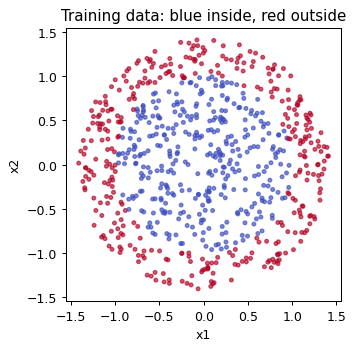

This task has only two input features, so we can see the entire problem. That makes it a useful place to understand what a representation can change.

## Why a familiar model struggles here

A familiar starting point is logistic regression. Using the raw coordinates, it first combines them into a score:

$$z=w_1x_1+w_2x_2+b.$$

Every symbol has a job:

| Symbol | Plain meaning | What it does here |
| --- | --- | --- |
| $x_1,x_2$ | The point’s coordinates | Supply the input measurements |
| $w_1,w_2$ | Learned multipliers, called weights | Control each coordinate’s influence |
| $b$ | A learned offset, called bias | Shift the score up or down |
| $z$ | The combined score | Provide the value converted to a probability |

The model learns the two weights and bias from examples.

The score $z$ can be positive or negative. Logistic regression passes it through a function called **sigmoid**, which converts it into a probability estimate between zero and one. With the usual cutoff of one half, positive scores predict outside and nonpositive scores predict inside in our example.

The dividing boundary is therefore where the score is zero:

$$w_1x_1+w_2x_2+b=0.$$

That is the equation of a straight line. Changing the weights and bias moves or rotates the line, but it remains a line.

Look back at the points. The outside class wraps around the inside class. A line cuts the page into two sides; it cannot make an enclosed circular region. No amount of extra fitting changes that restriction on this particular model.

This does not mean all traditional machine learning methods fail on circles. Trees and other nonlinear methods can represent more complicated boundaries. We have found a mismatch between **one model and the features we gave it**.

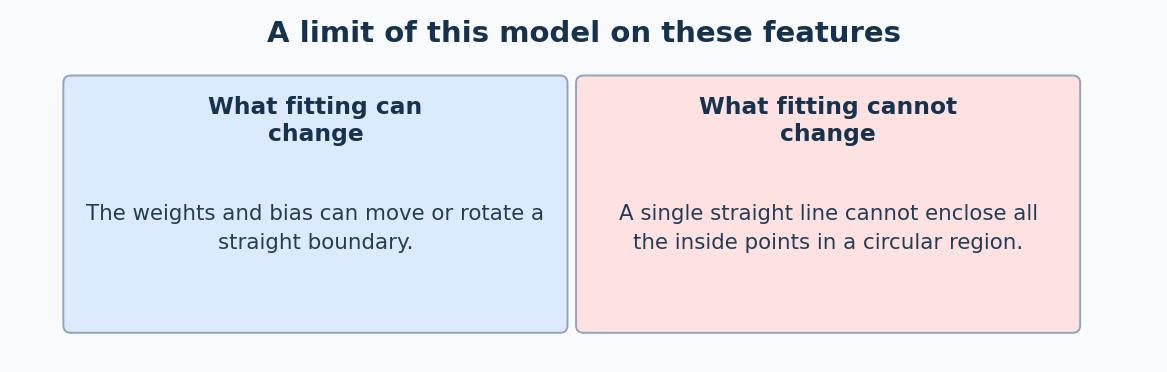

## Give the model a description that matches the problem

For a circle, horizontal and vertical position are not the most direct clues. What matters is distance from the center.

We can combine the coordinates into squared distance:

$$r^2=x_1^2+x_2^2.$$

Here $r$ means distance, and the superscript two means “square”: multiply a number by itself. Squaring both coordinates and adding them gives the square of the point's distance from the origin.

Take point A at $(0.3,0.4)$. Square the horizontal coordinate to get $0.09$. Square the vertical coordinate to get $0.16$. Add them:

$$r^2=0.09+0.16=0.25.$$

The circle has radius one, so its squared radius is also one. Since $0.25$ is below one, point A lies inside.

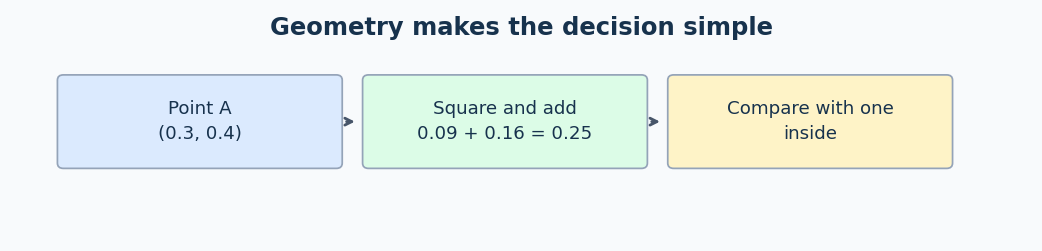

Now use exactly the same calculation on other points:

| Point | Coordinates | Squared distance | Decision |
| --- | --- | --- | --- |
| A | $(0.3,0.4)$ | $0.09+0.16=0.25$ | Inside |
| B | $(0.8,0.8)$ | $0.64+0.64=1.28$ | Outside |
| C | $(-0.8,-0.8)$ | $0.64+0.64=1.28$ | Outside |
| D | $(0,0)$ | $0+0=0$ | Inside |

Point C is on the opposite side from B, but both are equally far from the center. Squared distance captures that relationship immediately.

We do not even need to calculate a square root. Distance exceeds one exactly when squared distance exceeds one. The decision is now a simple comparison with one.

## What changed was the description of the data

The points did not move. Their correct labels did not change. We changed the numbers used to describe them.

A **representation** is a numerical description of data. Raw coordinates were one representation. Squared distance is another, and it makes this particular decision much easier.

A simple score $z=r^2-1$ is now enough. If it is positive, predict outside; otherwise, predict inside. A cutoff on one new feature creates a circle when viewed in the original coordinate plane.

This is an example of feature engineering: we supplied useful geometric knowledge. Because the exact rule is known, we could use it directly without training any model.

That raises the important practical question behind deep learning. Circles gave us an obvious feature. Handwriting, speech, and images often do not give us such a short recipe. We need a way to discover useful descriptions when writing all the rules ourselves becomes difficult.

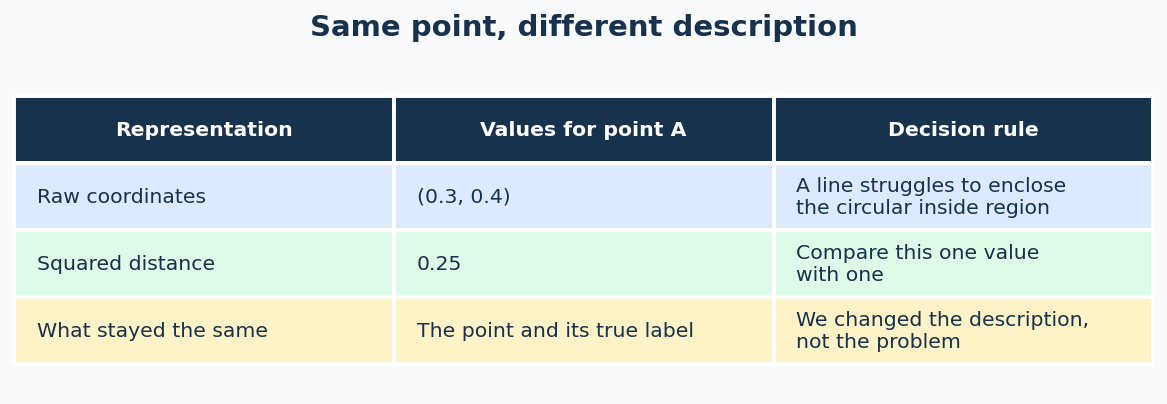

## Make the intermediate description adjustable

A **neural network** is a model made from connected stages of numerical computations. Each stage is called a **layer**. The stored weights and biases in these computations are its **parameters**: values that can change during learning.

Instead of calculating one fixed feature such as squared distance, a network calculates intermediate values through adjustable transformations. A **hidden layer** is one of these intermediate stages. Its output goes to another layer rather than directly becoming the final answer.

| Part of the network | Its job in the circle problem |
| --- | --- |
| Input | Receive the two coordinates |
| Hidden layers | Create adjustable intermediate descriptions |
| Nonlinear transformations | Let the response bend across input regions |
| Output | Produce the score used for the final decision |

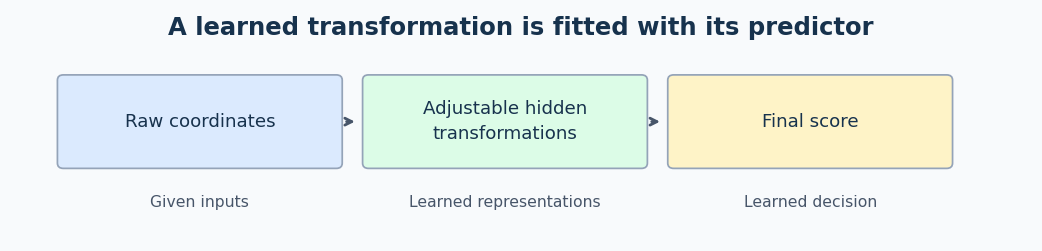

For example, a layer can combine the two coordinates into several scores. The next layer receives those scores and combines them again. The network therefore gets a chance to create a description that is useful for the task.

But repeatedly adding and multiplying is not enough on its own. If every stage were only a weighted sum plus an offset, the whole chain could be combined into one weighted sum plus an offset. We would still face the same straight-line limitation.

Networks therefore include **nonlinear transformations**—rules whose full behavior cannot be described by one weighted sum and offset. A simple example is ReLU: it keeps a positive score and replaces a negative score with zero. Its response bends at zero. Combining such responses allows different behavior in different input regions.

The point is not that ReLU knows anything about circles. It gives the adjustable model a richer set of possible shapes to work with.

## How does the network know which descriptions are useful?

The intermediate values start without a useful meaning. The model makes predictions, compares them with the correct labels, and receives a **loss**: a number measuring prediction mismatch under a chosen rule.

The prediction depends on both the final calculation and the earlier transformations. Training can therefore use that mismatch to guide changes throughout the model, rather than only changing the last step.

This is called **representation learning**: useful intermediate descriptions are learned as part of learning the task. Fitting the intermediate transformations and the final predictor together is called **end-to-end learning**.

For the circle, the network may learn combinations that approximate the circular boundary. We should not assume that one hidden value becomes exactly squared distance. Useful information can be spread across several values, and those values may not have simple names.

In the companion, the network receives raw coordinates and labels. We never supply squared distance to it. That lets us observe whether it can find a useful transformation of its own.

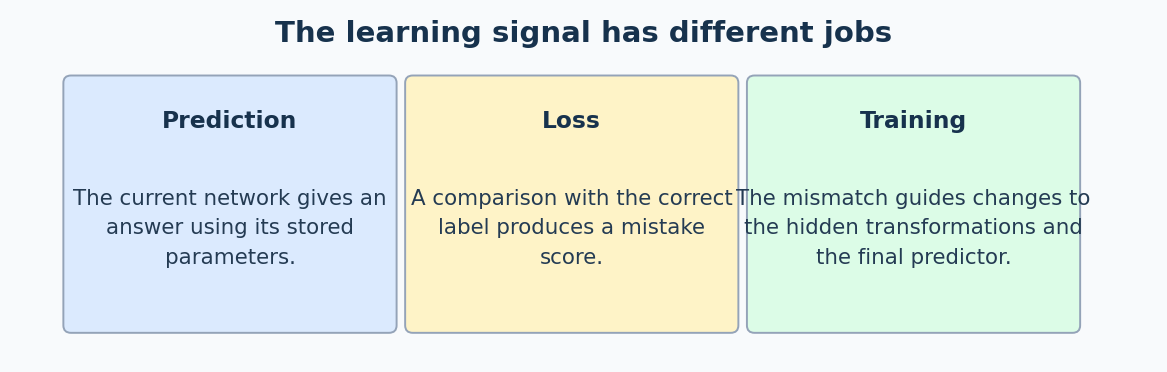

## Why is it called deep learning?

“Deep” describes a sequence of learned processing layers. A later layer can combine useful responses from earlier layers into another description.

For an image, simple local brightness changes might help identify edges. Combinations of such responses might become useful for larger shapes. Those combinations can then support recognizing a digit or object.

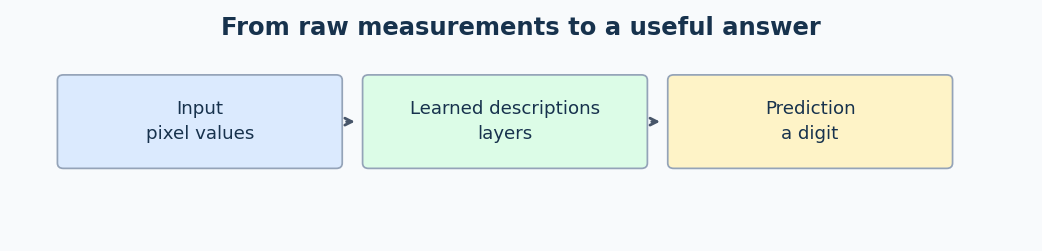

This is an intuition for layered computation, not a promise that every network contains a clearly labeled edge layer or shape layer. We have to inspect a model before assigning meanings to its hidden values.

These names describe different aspects of a model:

| Term | What it counts | Everyday picture |
| --- | --- | --- |
| Depth | Successive processing layers | More stages in a journey |
| Width | Units within a layer | More calculations at the same stage |
| Training examples | Input–target pairs available for learning | More examples to learn from |
| Training repetitions | How often we revisit learning data | More rounds of practice |

Adding practice or examples does not make the architecture deeper.

Our companion has two hidden layers, each with sixteen units. The circle does not require this particular depth; even one sufficiently wide hidden layer can approximate its boundary. We use the small network to demonstrate learned representations, not to claim that deeper is always necessary or better.

## Let the comparison answer the original question

We compare three fitted models on the same examples:

| Model | Description it receives |
| --- | --- |
| Logistic regression | Raw horizontal and vertical coordinates |
| Logistic regression with a designed feature | Squared distance, calculated using our geometric knowledge |
| Small neural network | Raw coordinates; its intermediate transformations are adjustable |

The examples have separate jobs. **Training examples** change parameters. **Validation examples** choose a saved parameter state, called a checkpoint. **Test examples** are reserved for evaluating the final choice on unseen points.

Keeping those roles separate matters. A model can fit the examples it saw without handling new ones well. This is **overfitting**. Using test results to choose settings would also make the final comparison less independent.

The saved run gives about fifty-two percent test accuracy for raw-coordinate logistic regression and about ninety-nine percent for both other fitted models. **Accuracy** means the fraction of examples assigned the correct label.

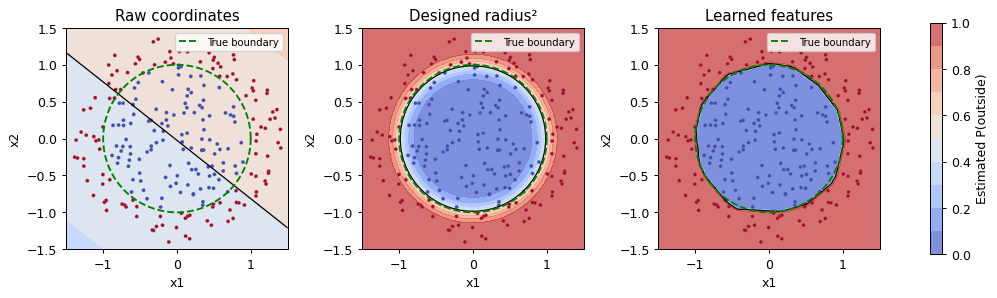

Read the picture from left to right. The first model has a straight boundary. The middle model follows the circle because we gave it squared distance. The last learns an approximately circular boundary without being handed that feature.

The dashed green circle marks the true boundary. Colored backgrounds show probability estimates, and the dots are test observations. The square plot's corners extend beyond the sampled disk, so predictions there have no test support.

The exact geometry rule reaches perfect accuracy because it is the rule used to generate the labels. The network demonstrates something useful, but it does not beat the simpler model supplied with the right feature. Small numerical differences can occur across environments.

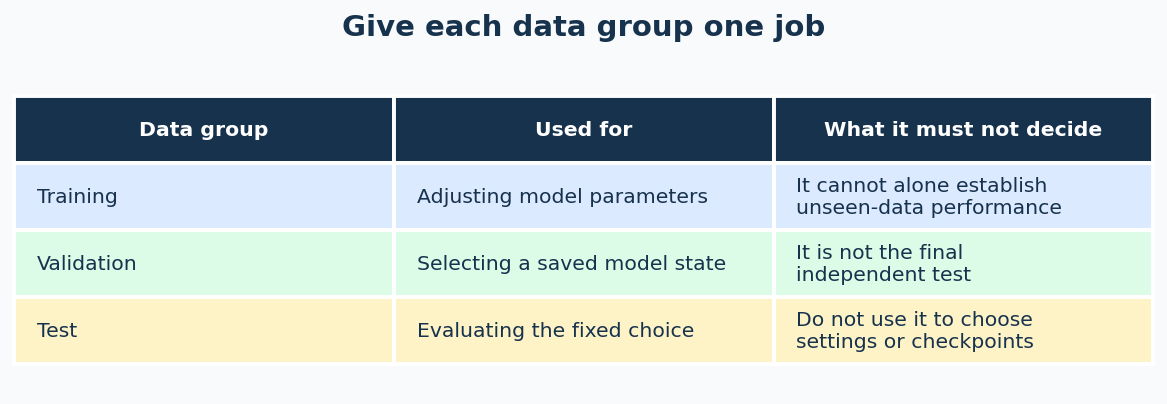

## Where this becomes useful in practice

The circle is easy because we know its geometry. The same question about representations appears in harder tasks.

For handwriting, useful patterns involve groups of pixels despite changes in writing style. For speech, patterns must remain useful across different speakers and background sounds. For text, a word's role may depend on the surrounding words rather than the word alone.

Deep learning can be useful when learning these relationships is more practical than prescribing every relevant feature by hand. It does not remove human choices. We still choose data, objectives, model structures, and ways to evaluate the result.

Flexibility has costs. Larger networks can need substantial data and computation. A model may learn an accidental shortcut—for example, a background associated with a label—rather than the pattern we intended. Hidden representations can also be difficult to interpret.

Use a known rule when it already solves the problem. When meaningful features are available, compare simple methods first. A neural network earns its place when its results justify the extra complexity.

The reason to consider deep learning is that a useful description can be learned along with the prediction rule. The reason to keep comparing it with simpler approaches is that learning that description is not always necessary.

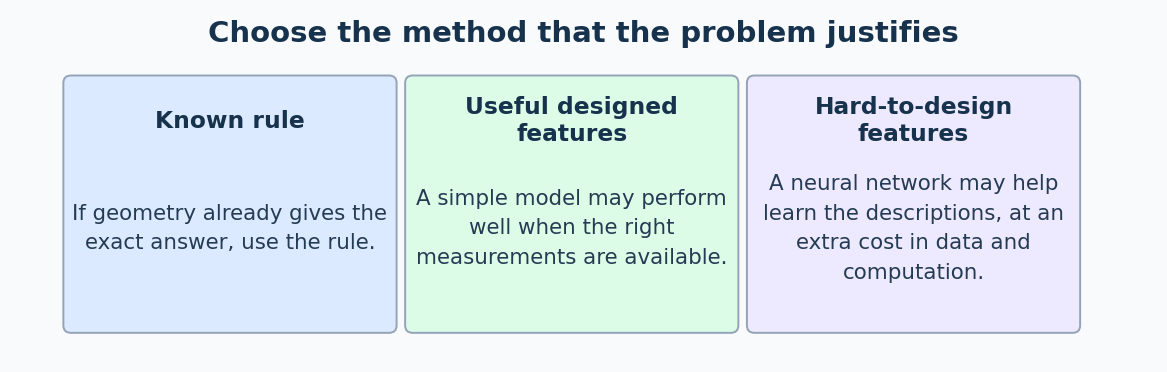

## Generalization has more than one shape

The **bias-variance tradeoff** separates systematic error from sensitivity to the sampled training set. A model with high bias is too restricted and underfits; a model with high variance changes substantially across training samples and can overfit. Irreducible noise remains even for an ideal learner.

**Underparameterization** means the model cannot represent the useful pattern. **Overparameterization** means it has more adjustable degrees of freedom than are needed, but that does not automatically imply poor test performance: optimization, inductive bias, and regularization matter. In some modern settings, test error first rises as capacity increases, then falls again after a model becomes sufficiently overparameterized. This non-monotonic pattern is called **double descent**. It is an empirical phenomenon, not a license to ignore validation data or data quality.

The companion simulates a simple capacity curve so the two descent regions are visible. The curve is illustrative; real networks need repeated data splits and controlled experiments.